# 01 — Red BBN con `pynucastro` y gráficas de red

Construye una red ligera de BBN con `pynucastro`, guarda `bbn_network.py`, exporta tablas de núcleos/reacciones/aristas y genera los grafos de red para la simulación con $t_0 = 50$ s evaluada en los snapshots de 50, 200 y 1000 s.

La red base incluye $n$, $p$, D, T, $^3$He, $^4$He, $^7$Li y $^7$Be. El código intenta además una configuración algo más fina con $^6$Li y deja preparada una tabla diagnóstica para reacciones inversas disponibles. La integración principal mantiene las tasas directas de ReacLib por estabilidad numérica; AlterBBN se usa después como benchmark externo de precisión.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
DATA_DIR = BASE / "data"
TAB_DIR = BASE / "tables"

for d in [FIG_DIR, DATA_DIR, TAB_DIR]:
    d.mkdir(exist_ok=True)

print("BASE:", BASE)
print("FIG_DIR:", FIG_DIR)
print("DATA_DIR:", DATA_DIR)

BASE: /home/daniel/GitHub/BNN_simulation/main
FIG_DIR: /home/daniel/GitHub/BNN_simulation/main/figures
DATA_DIR: /home/daniel/GitHub/BNN_simulation/main/data


In [2]:
# ============================================================
# Construcción de la red con pynucastro
# ============================================================
# Si esta celda falla:
#   pip install pynucastro

import pynucastro as pyna

# Nota: usamos h1/h2/h3 para que el naming sea estable en la salida generada.
# pynucastro puede imprimir luego H1, H2, H3 en bbn.names.
BASE_NUCLEI = [
    "n", "h1", "h2", "h3", "he3", "he4", "li7", "be7",
]

# Mejora opcional respecto al modelo base: intentar incluir Li6.
# Si la librería instalada no encuentra tasas cerradas para Li6, el código cae
# automáticamente a la red de masa 7 usada en la versión estable.
TRY_INCLUDE_LI6 = True

# Las reacciones inversas por balance detallado son físicamente importantes para
# una BBN de precisión, pero suelen hacer mucho más rígida la red y pueden romper
# una integración didáctica con trayectoria termodinámica impuesta. Por eso aquí
# se exporta un diagnóstico separado, pero la red principal se integra sin forzar
# with_reverse=True. AlterBBN será el benchmark de precisión.
EXPORT_REVERSE_DIAGNOSTIC = True
WITH_REVERSE_MAIN = False

rl = pyna.ReacLibLibrary()

def build_library(include_li6=False, with_reverse=False):
    names = list(BASE_NUCLEI)
    if include_li6:
        names.insert(names.index("li7"), "li6")
    nuclei = [pyna.Nucleus(name) for name in names]
    return rl.linking_nuclei(nuclei, with_reverse=with_reverse), nuclei

# Intento de red principal: Li6 si es posible; si no, red base.
network_attempts = []
if TRY_INCLUDE_LI6:
    network_attempts.append(("light_network_with_li6_direct", True, WITH_REVERSE_MAIN))
network_attempts.append(("light_network_mass7_direct", False, WITH_REVERSE_MAIN))

last_error = None
for label, include_li6, with_reverse in network_attempts:
    try:
        bbn_library, selected_nuclei = build_library(include_li6=include_li6, with_reverse=with_reverse)
        bbn_net = pyna.PythonNetwork(libraries=[bbn_library])
        network_label = label
        break
    except Exception as exc:
        last_error = exc
        print(f"[red] Falló {label}: {exc}")
else:
    raise RuntimeError("No se pudo construir ninguna red BBN") from last_error

bbn_net.write_network("bbn_network.py")

print(f"Red seleccionada: {network_label}")
print(bbn_net)
print(f"Número de núcleos: {len(bbn_net.unique_nuclei)}")
print(f"Número de rates: {len(bbn_net.rates)}")

# Diagnóstico opcional de tasas inversas. No se usa para integrar, solo para
# documentar qué red más rígida podría probarse en una segunda iteración local.
if EXPORT_REVERSE_DIAGNOSTIC:
    reverse_rows = []
    for include_li6 in ([True, False] if TRY_INCLUDE_LI6 else [False]):
        try:
            rev_library, rev_nuclei = build_library(include_li6=include_li6, with_reverse=True)
            rev_net = pyna.PythonNetwork(libraries=[rev_library])
            for i, r in enumerate(rev_net.rates):
                reverse_rows.append({
                    "network": "with_li6" if include_li6 else "mass7",
                    "index": i,
                    "rate": str(r),
                    "reactants": " + ".join(str(x) for x in r.reactants),
                    "products": " + ".join(str(x) for x in r.products),
                    "Q_MeV": getattr(r, "Q", np.nan),
                })
        except Exception as exc:
            reverse_rows.append({
                "network": "with_li6" if include_li6 else "mass7",
                "index": -1,
                "rate": "FAILED",
                "reactants": "",
                "products": "",
                "Q_MeV": np.nan,
                "error": str(exc),
            })
    pd.DataFrame(reverse_rows).to_csv(DATA_DIR / "bbn_network_reverse_diagnostic.csv", index=False)


Red seleccionada: light_network_with_li6_direct
n ⟶ p + e⁻ + 𝜈
H3 ⟶ He3 + e⁻ + 𝜈
He3 + e⁻ ⟶ H3 + 𝜈
Be7 + e⁻ ⟶ Li7 + 𝜈
n + p ⟶ H2 + 𝛾
p + p ⟶ H2 + e⁺ + 𝜈
p + p + e⁻ ⟶ H2 + 𝜈
H2 + n ⟶ H3 + 𝛾
H2 + p ⟶ He3 + 𝛾
H2 + H2 ⟶ He4 + 𝛾
H2 + He4 ⟶ Li6 + 𝛾
H3 + p ⟶ He4 + 𝛾
H3 + He4 ⟶ Li7 + 𝛾
He3 + n ⟶ He4 + 𝛾
He3 + p ⟶ He4 + e⁺ + 𝜈
He3 + He4 ⟶ Be7 + 𝛾
Li6 + n ⟶ Li7 + 𝛾
Li6 + p ⟶ Be7 + 𝛾
H2 + H2 ⟶ n + He3
H2 + H2 ⟶ p + H3
H3 + H2 ⟶ n + He4
He3 + n ⟶ p + H3
He3 + H2 ⟶ p + He4
He3 + H3 ⟶ H2 + He4
Li6 + n ⟶ He4 + H3
Li6 + p ⟶ He4 + He3
Li6 + H2 ⟶ n + Be7
Li6 + H2 ⟶ p + Li7
Li7 + p ⟶ He4 + He4
Be7 + n ⟶ p + Li7
Be7 + n ⟶ He4 + He4
H3 + H3 ⟶ n + n + He4
He3 + H3 ⟶ n + p + He4
He3 + He3 ⟶ p + p + He4
Li7 + H2 ⟶ n + He4 + He4
Be7 + H2 ⟶ p + He4 + He4
Li7 + H3 ⟶ n + n + He4 + He4
Li7 + He3 ⟶ n + p + He4 + He4
Be7 + H3 ⟶ n + p + He4 + He4
Be7 + He3 ⟶ p + p + He4 + He4
n + p + He4 ⟶ Li6 + 𝛾
n + p + p ⟶ p + H2

Número de núcleos: 9
Número de rates: 42


In [3]:
# ============================================================
# Tabla de núcleos de la red
# ============================================================
# Se usará tanto en plots como en la memoria.

nuclei_rows = []
for i, n in enumerate(bbn_net.unique_nuclei):
    A = getattr(n, "A", np.nan)
    Z = getattr(n, "Z", np.nan)
    N = getattr(n, "N", np.nan)
    nuclei_rows.append({
        "index": i,
        "name": str(n),
        "A": A,
        "Z": Z,
        "N": N,
        "A_minus_2Z": A - 2 * Z,
    })

nuclei = pd.DataFrame(nuclei_rows)
nuclei.to_csv(DATA_DIR / "bbn_network_nuclei.csv", index=False)
nuclei

,index,name,A,Z,N,A_minus_2Z
0,0,n,1,0,1,1
1,1,p,1,1,0,-1
2,2,d,2,1,1,0
3,3,t,3,1,2,1
4,4,He3,3,2,1,-1
5,5,He4,4,2,2,0
6,6,Li6,6,3,3,0
7,7,Li7,7,3,4,1
8,8,Be7,7,4,3,-1


In [4]:
# ============================================================
# Tabla de reacciones
# ============================================================

rate_rows = []
for i, r in enumerate(bbn_net.rates):
    rate_rows.append({
        "index": i,
        "rate": str(r),
        "reactants": " + ".join(str(x) for x in r.reactants),
        "products": " + ".join(str(x) for x in r.products),
        "Q_MeV": getattr(r, "Q", np.nan),
    })

rates_df = pd.DataFrame(rate_rows)
rates_df.to_csv(DATA_DIR / "bbn_network_rates.csv", index=False)
rates_df.head(30)

,index,rate,reactants,products,Q_MeV
0,0,n ⟶ p + e⁻ + 𝜈,n,p,0.78230
1,1,H3 ⟶ He3 + e⁻ + 𝜈,t,He3,0.01860
2,2,He3 + e⁻ ⟶ H3 + 𝜈,He3,t,-0.01900
3,3,Be7 + e⁻ ⟶ Li7 + 𝜈,Be7,Li7,0.86300
4,4,n + p ⟶ H2 + 𝛾,n + p,d,2.22457
5,5,p + p ⟶ H2 + e⁺ + 𝜈,p + p,d,1.44206
6,6,p + p + e⁻ ⟶ H2 + 𝜈,p + p,d,1.44206
7,7,H2 + n ⟶ H3 + 𝛾,n + d,t,6.25737
8,8,H2 + p ⟶ He3 + 𝛾,p + d,He3,5.49300
9,9,H2 + H2 ⟶ He4 + 𝛾,d + d,He4,23.84700


## Integración rápida para colorear los nodos

El notebook 02 hace la integración principal desde $t_0=50$ s hasta $1000$ s. Aquí solo se integra rápidamente la misma trayectoria para asignar colores a los nodos del grafo de red en los tres snapshots del enunciado.

In [5]:
# ============================================================
# Integración rápida t0 = 50 s para colorear la red
# ============================================================

from scipy.integrate import solve_ivp
import importlib.util

from thermo_model import make_thermo_functions

snapshots_path = DATA_DIR / "bbn_assignment_snapshots.csv"
if not snapshots_path.exists():
    raise FileNotFoundError(
        f"No encuentro {snapshots_path}. Ejecuta antes el notebook 00."
    )

snapshots = pd.read_csv(snapshots_path)
thermo = make_thermo_functions(snapshots, eta10_ref=6.10)
T9_of_t = thermo.T9_of_t
T_of_t = thermo.T_of_t
rho_of_t = thermo.rho_of_t

spec = importlib.util.spec_from_file_location("bbn_network", BASE / "bbn_network.py")
bbn = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bbn)

name_to_i = {str(name): i for i, name in enumerate(bbn.names)}
norm_to_real = {str(name).strip().lower(): str(name) for name in bbn.names}

print("Núcleos importados desde bbn_network.py:", bbn.names)

# Aliases robustos para distintas nomenclaturas de pynucastro/ReacLib.
ALIASES = {
    "n":   ("n", "neutron"),
    "p":   ("p", "h1", "H1", "proton"),
    "d":   ("d", "h2", "H2"),
    "t":   ("t", "h3", "H3"),
    "he3": ("he3", "He3", "HE3"),
    "he4": ("he4", "He4", "HE4", "alpha"),
    "li7": ("li7", "Li7", "LI7"),
    "be7": ("be7", "Be7", "BE7"),
}

def nuc_name(key):
    """Devuelve el nombre exacto del núcleo tal como aparece en bbn.names."""
    for candidate in ALIASES[key]:
        candidate = str(candidate).strip()

        if candidate in name_to_i:
            return candidate

        cand_norm = candidate.lower()
        if cand_norm in norm_to_real:
            return norm_to_real[cand_norm]

    raise KeyError(
        f"No encuentro el núcleo '{key}'. Nombres disponibles en la red: {bbn.names}"
    )

def nuc_index(key):
    return name_to_i[nuc_name(key)]

def nuc_col(prefix, key):
    return f"{prefix}_{nuc_name(key).replace(' ', '')}"

CANON = {key: nuc_name(key) for key in ALIASES}
print("Aliases usados:", CANON)

Y0 = np.zeros(bbn.nnuc)

# n/p = 1/7 -> Yn = 1/8, Yp = 7/8.
# Para A=1, Y coincide numéricamente con X en la condición inicial.
Y0[nuc_index("n")] = 1.0 / 8.0
Y0[nuc_index("p")] = 7.0 / 8.0

print("Condición inicial no nula:")
for name, value in zip(bbn.names, Y0):
    if value > 0:
        print(f"  {name:>4s}: {value:.6e}")

def rhs_var(t, Y):
    Y_safe = np.maximum(np.asarray(Y, dtype=float), 0.0)
    return np.asarray(
        bbn.rhs(t, Y_safe, float(rho_of_t(t)), float(T_of_t(t))),
        dtype=float,
    )

t_eval = np.unique(np.concatenate([
    np.geomspace(50.0, 1000.0, 280),
    np.array([50.0, 200.0, 1000.0]),
]))

sol_quick = solve_ivp(
    rhs_var,
    (50.0, 1000.0),
    Y0,
    method="LSODA",
    t_eval=t_eval,
    rtol=1.0e-6,
    atol=1.0e-30,
    max_step=2.0,
)

print("success:", sol_quick.success)
print("message:", sol_quick.message)
print("n_eval:", len(sol_quick.t))

if not sol_quick.success:
    raise RuntimeError(sol_quick.message)

Núcleos importados desde bbn_network.py: ['n', 'H1', 'H2', 'H3', 'He3', 'He4', 'Li6', 'Li7', 'Be7']
Aliases usados: {'n': 'n', 'p': 'H1', 'd': 'H2', 't': 'H3', 'he3': 'He3', 'he4': 'He4', 'li7': 'Li7', 'be7': 'Be7'}
Condición inicial no nula:
     n: 1.250000e-01
    H1: 8.750000e-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5000000000000D+02   r2 =  0.1786465958184D-26
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5000000000000D+02   r2 =  0.1786465958184D-26
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5000000000000D+02   r2 =  0.1786465958

## Grafo manual de la red

El grafo se dibuja en el plano $(Z, A-2Z)$. Los nodos se colorean según $\log_{10} X_i$ y las flechas se extraen de las reacciones reales de `pynucastro`.

Esta versión **canoniza los nombres** de reactivos y productos. Por ejemplo, si una tasa aparece con `p` pero la red usa `H1`, la arista se dibuja igualmente desde/hacia `H1`.

In [6]:
# ============================================================
# Utilidades para canonicalizar nombres y construir aristas
# ============================================================

from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

# Posiciones de los núcleos desde el bbn_network.py generado.
def get_AZ_from_bbn(name):
    i = name_to_i[str(name)]
    return int(bbn.A[i]), int(bbn.Z[i])

positions = {}
for name in bbn.names:
    A, Z = get_AZ_from_bbn(name)
    positions[str(name)] = (Z, A - 2 * Z)

available = set(positions.keys())
available_norm = {name.lower(): name for name in available}

def canonical_nuc_name(x):
    """
    Convierte nombres de pynucastro/ReacLib al nombre real usado por bbn.names.

    Ejemplos:
      p, h1, H1  -> H1 si bbn.names usa H1
      d, h2, H2  -> H2
      t, h3, H3  -> H3
    """
    s = str(x).strip()

    # Primero, si coincide exactamente con la red, perfecto.
    if s in available:
        return s

    # Alias físico -> clave normalizada.
    alias_norm = {
        "p": "h1",
        "proton": "h1",
        "h1": "h1",
        "d": "h2",
        "h2": "h2",
        "t": "h3",
        "h3": "h3",
        "alpha": "he4",
        "he4": "he4",
        "he3": "he3",
        "li7": "li7",
        "be7": "be7",
        "n": "n",
        "neutron": "n",
    }

    target_norm = alias_norm.get(s.lower(), s.lower())

    # Si la red usa H1 y target_norm es h1, esto devuelve H1.
    if target_norm in available_norm:
        return available_norm[target_norm]

    return s

# Flechas extraídas de las tasas reales de pynucastro.
def rate_edges_from_network(rates):
    edges = []
    seen = set()

    for r in rates:
        reactants = [canonical_nuc_name(x) for x in r.reactants]
        products = [canonical_nuc_name(x) for x in r.products]

        reactants = [x for x in reactants if x in available]
        products = [x for x in products if x in available]

        for a in reactants:
            for b in products:
                if a == b:
                    continue
                key = (a, b)
                if key not in seen:
                    seen.add(key)
                    edges.append({
                        "from": a,
                        "to": b,
                        "rate": str(r),
                    })

    return edges

network_edges = rate_edges_from_network(bbn_net.rates)
edge_table = pd.DataFrame(network_edges)
edge_table.to_csv(DATA_DIR / "bbn_network_edges_for_plot.csv", index=False)

print(f"Flechas dibujadas: {len(edge_table)}")
print("Flechas con H1/protón:")
print(edge_table[(edge_table["from"] == CANON["p"]) | (edge_table["to"] == CANON["p"])].head(30))

edge_table.head(30)

Flechas dibujadas: 48
Flechas con H1/protón:
   from   to                           rate
0     n   H1                 n ⟶ p + e⁻ + 𝜈
5    H1   H2                 n + p ⟶ H2 + 𝛾
8    H1  He3               H2 + p ⟶ He3 + 𝛾
13   H1  He4               H3 + p ⟶ He4 + 𝛾
23   H1  Be7              Li6 + p ⟶ Be7 + 𝛾
26   H2   H1               H2 + H2 ⟶ p + H3
28  He3   H1               He3 + n ⟶ p + H3
37  Li6   H1             Li6 + H2 ⟶ p + Li7
39  Be7   H1              Be7 + n ⟶ p + Li7
41   H3   H1         He3 + H3 ⟶ n + p + He4
44  Li7   H1  Li7 + He3 ⟶ n + p + He4 + He4
47   H1  Li6          n + p + He4 ⟶ Li6 + 𝛾


,from,to,rate
0,n,H1,n ⟶ p + e⁻ + 𝜈
1,H3,He3,H3 ⟶ He3 + e⁻ + 𝜈
2,He3,H3,He3 + e⁻ ⟶ H3 + 𝜈
3,Be7,Li7,Be7 + e⁻ ⟶ Li7 + 𝜈
4,n,H2,n + p ⟶ H2 + 𝛾
5,H1,H2,n + p ⟶ H2 + 𝛾
6,n,H3,H2 + n ⟶ H3 + 𝛾
7,H2,H3,H2 + n ⟶ H3 + 𝛾
8,H1,He3,H2 + p ⟶ He3 + 𝛾
9,H2,He3,H2 + p ⟶ He3 + 𝛾


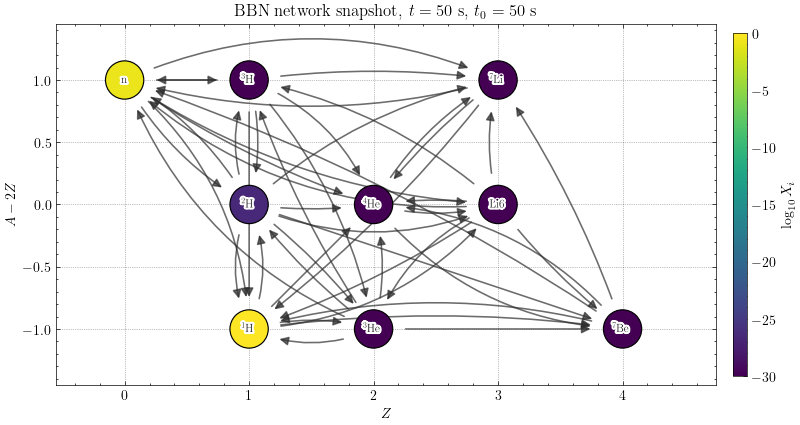

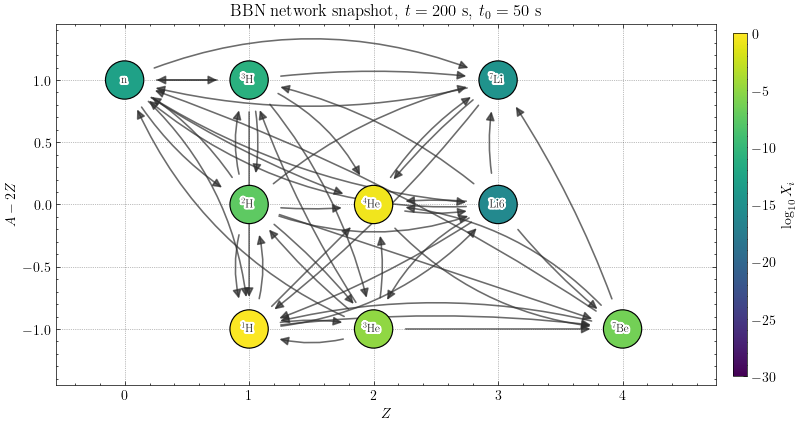

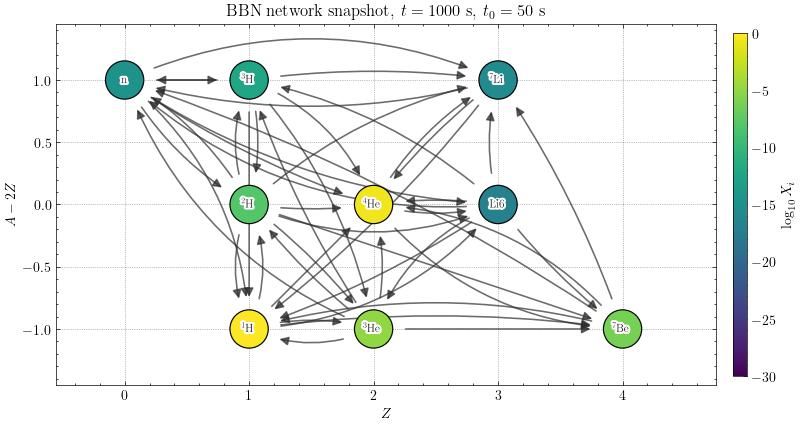

In [7]:
# ============================================================
# Plot del grafo para los snapshots 50, 200 y 1000 s
# ============================================================

PRETTY_NUC = {
    CANON["n"]: "n",
    CANON["p"]: r"$^1$H",
    CANON["d"]: r"$^2$H",
    CANON["t"]: r"$^3$H",
    CANON["he3"]: r"$^3$He",
    CANON["he4"]: r"$^4$He",
    CANON["li7"]: r"$^7$Li",
    CANON["be7"]: r"$^7$Be",
}

def interpolate_Y_at(sol, t):
    if not sol.success:
        raise RuntimeError(sol.message)
    return np.array([np.interp(t, sol.t, sol.y[i, :]) for i in range(sol.y.shape[0])])

def draw_arrow(ax, a, b, idx=0):
    xa, ya = positions[a]
    xb, yb = positions[b]

    # Variamos curvatura para reducir solapes.
    rad_values = [-0.22, -0.14, -0.07, 0.07, 0.14, 0.22, 0.0]
    rad = rad_values[idx % len(rad_values)]

    arrow = FancyArrowPatch(
        (xa, ya),
        (xb, yb),
        arrowstyle="-|>",
        mutation_scale=13,
        lw=1.15,
        color="0.18",
        alpha=0.70,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=23,
        shrinkB=23,
        zorder=1,
    )
    ax.add_patch(arrow)

def plot_network_snapshot(t, outname):
    Y = np.maximum(interpolate_Y_at(sol_quick, t), 0.0)
    X = Y * bbn.A

    fig, ax = plt.subplots(figsize=(8.2, 5.2))

    # Flechas antes que nodos.
    for k, row in edge_table.iterrows():
        draw_arrow(ax, row["from"], row["to"], idx=k)

    xs, ys, cs, labels = [], [], [], []
    for name in bbn.names:
        name = str(name)
        x, y = positions[name]
        xs.append(x)
        ys.append(y)
        labels.append(PRETTY_NUC.get(name, name))
        cs.append(max(float(X[name_to_i[name]]), 1e-30))

    sc = ax.scatter(
        xs,
        ys,
        c=np.log10(cs),
        s=760,
        cmap="viridis",
        vmin=-30,
        vmax=0,
        edgecolors="black",
        linewidths=0.85,
        zorder=3,
    )

    for x, y, label in zip(xs, ys, labels):
        ax.text(
            x, y, label,
            ha="center", va="center",
            fontsize=8.5,
            color="black",
            zorder=4,
            path_effects=[pe.withStroke(linewidth=3.0, foreground="white")],
        )
    cbar = fig.colorbar(
        sc,
        ax=ax,
        shrink=0.70,     # altura relativa de la colorbar
        fraction=0.035,  # anchura de la colorbar
        pad=0.025,       # separación respecto al plot
        aspect=25,       # relación alto/ancho
    )
    cbar.set_label(r"$\log_{10} X_i$")


    ax.set_xlabel(r"$Z$")
    ax.set_ylabel(r"$A - 2Z$")
    ax.set_title(fr"BBN network snapshot, $t={t:.0f}$ s, $t_0=50$ s")

    ax.set_xlim(-0.55, 4.75)
    ax.set_ylim(-1.45, 1.45)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="major", ls=":", alpha=0.50)

    fig.tight_layout()
    fig.savefig(FIG_DIR / outname)
    plt.show()

plot_network_snapshot(50.0, "fig_network_t0_50_snapshot_50s.pdf")
plot_network_snapshot(200.0, "fig_network_t0_50_snapshot_200s.pdf")
plot_network_snapshot(1000.0, "fig_network_t0_50_snapshot_1000s.pdf")

In [8]:
# ============================================================
# Sanity checks exportados para la memoria / depuración
# ============================================================

summary = {
    "n_nuclei": len(bbn.names),
    "n_rates": len(bbn_net.rates),
    "n_edges_for_plot": len(edge_table),
    "with_reverse": WITH_REVERSE,
    "canon_n": CANON["n"],
    "canon_p": CANON["p"],
    "canon_d": CANON["d"],
    "canon_t": CANON["t"],
    "canon_he3": CANON["he3"],
    "canon_he4": CANON["he4"],
    "canon_li7": CANON["li7"],
    "canon_be7": CANON["be7"],
}

pd.DataFrame([summary]).to_csv(DATA_DIR / "bbn_network_summary.csv", index=False)
summary

NameError: name 'WITH_REVERSE' is not defined